# Prac W6 - Performance contd. and Loss Functions

**Aims:**
- To gain some practical experience in evaluating supervised machine learning models

(**1**) Train a $k$-NN model (choose some reasonable value for $k$) on the training set and calculate a confusion matrix for the hold-out validation set

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/r9/h_t0mx7s19b78_8twtlhf7s00000gn/T/ipykernel_16601/2504203038.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  return pd.read_csv(filepath, sep='\s+', header=None)


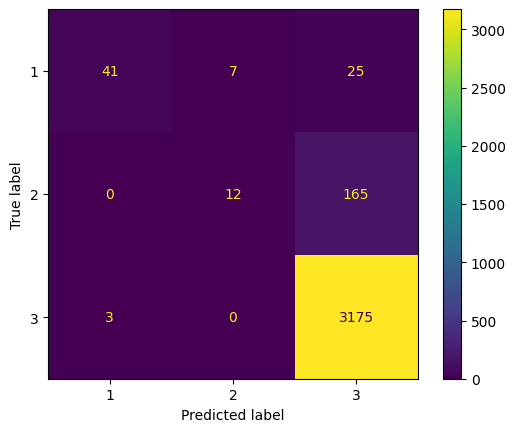

In [55]:
import pandas as pd 
import numpy as np

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

def load_data(is_train: bool) -> pd.DataFrame:
    filepath: str = "./datasets/ann-train.data" if is_train else "./datasets/ann-test.data"
    return pd.read_csv(filepath, sep='\s+', header=None)

train_df: pd.DataFrame = load_data(True)
train_X: np.ndarray = train_df.iloc[:, :-1].to_numpy()
train_y: np.ndarray = train_df.iloc[:, -1].to_numpy()

test_df: pd.DataFrame = load_data(False)
test_X: np.ndarray = test_df.iloc[:, : -1].to_numpy()
test_y: np.ndarray = test_df.iloc[:, -1].to_numpy()


def grid_search(k_grid: np.ndarray, X: np.ndarray, y: np.ndarray) -> Pipeline:
    best_model: Pipeline
    best_acc_score: float = 0

    for k in k_grid:
        pipeline: Pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(k))
        scores: np.ndarray = cross_val_score(pipeline, X, y, cv=5)
        mean_score: float = np.mean(scores)
        if (mean_score > best_acc_score):
            best_model = pipeline 

    best_model.fit(X, y)
    return best_model

def plot_confusion_matrix(model: Pipeline, X: np.ndarray, y: np.ndarray) -> None:
    y_pred: np.ndarray = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y, y_pred)

model: Pipeline = grid_search(np.arange(1, 24), train_X, train_y)
plot_confusion_matrix(model, test_X, test_y)

(**2**) Attempt to reproduce Example 4.5 from the Lindholm et al. textbook. You will need to:

- Convert the data into a binary classification problem
- Train a logistic regression model on the training data
- Evaluate the trained model to calculate a confusion matrix
- Vary the decesion threshold for the model as done in Example 4.5 and recalculate the confusion matrix

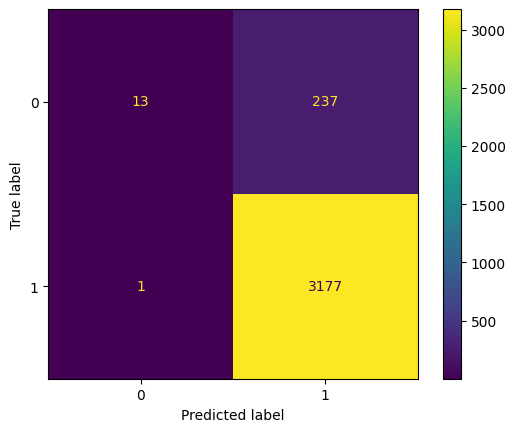

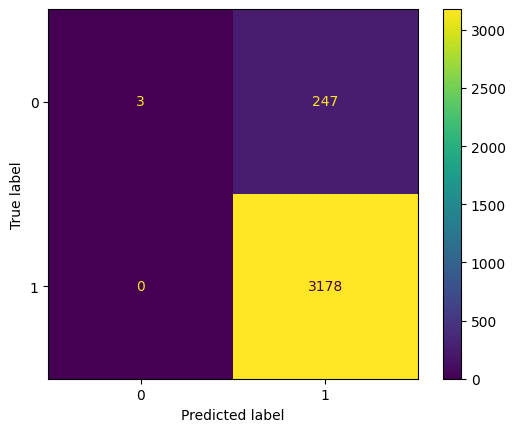

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import FixedThresholdClassifier

# Turn into binary 0 and 1
train_y = (train_y == 3).astype(int)
test_y = (test_y == 3).astype(int)

logistic_clf: LogisticRegression = LogisticRegression().fit(train_X, train_y)

def plot_confusion_matrix(model: LogisticRegression, X: np.ndarray, y: np.ndarray, 
    decision_threshold: float) -> None:
    model = FixedThresholdClassifier(model, threshold=decision_threshold)
    y_pred: np.ndarray = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y, y_pred)

plot_confusion_matrix(logistic_clf, test_X, test_y, 0.5)
plot_confusion_matrix(logistic_clf, test_X, test_y, 0.15)

(**3**) In Prac W4 we applied linear regression to a pokemon dataset, where the loss function was
sum of squared (or mean squared) error. Revisit this task but add 

(a) $L_2$

(b) $L_1$

regularisation to the loss function with some suitable value for the regularization hyperparameter.
Compare the coefficient values for your different trained models

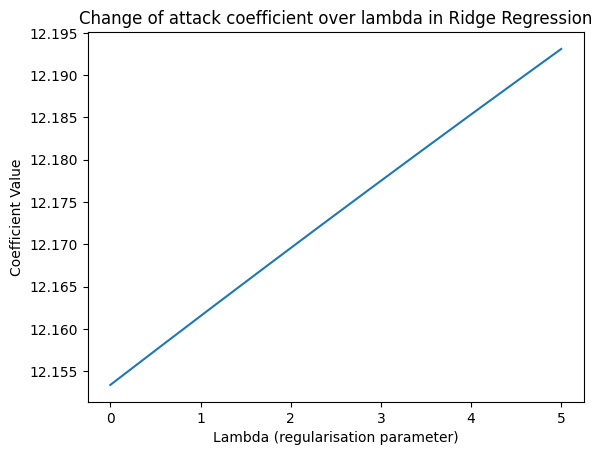

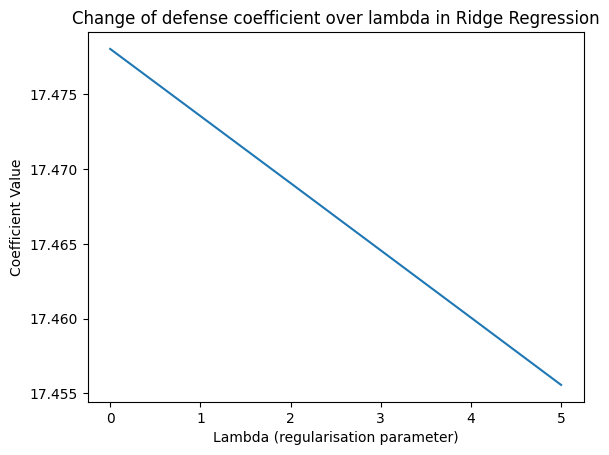

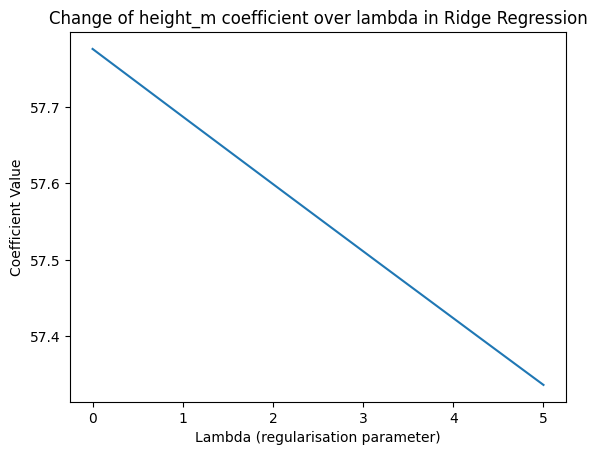

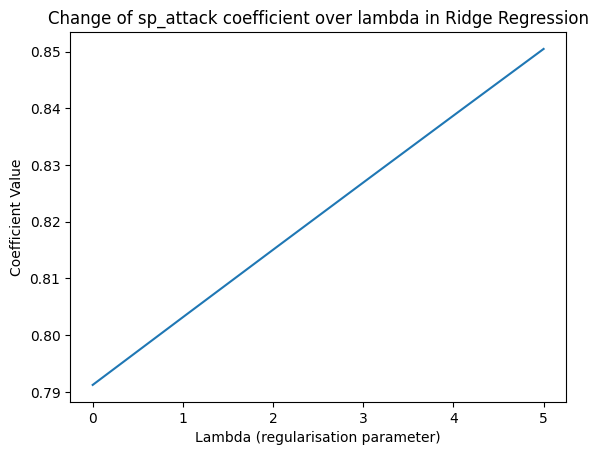

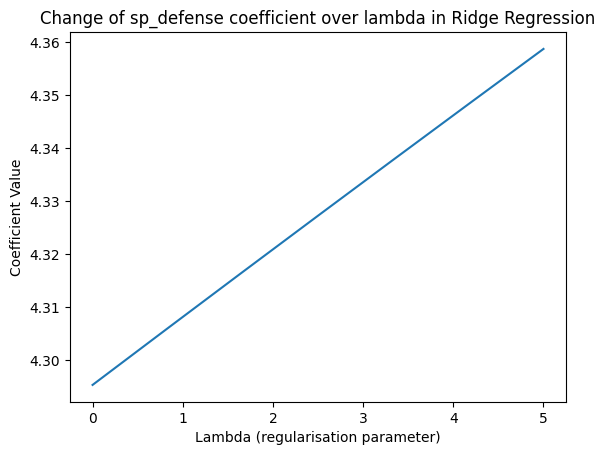

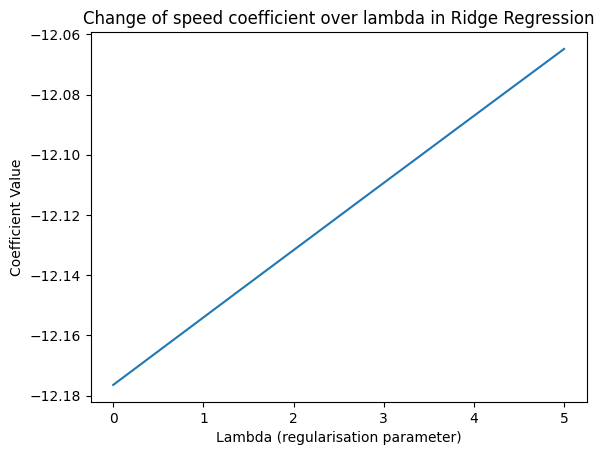

/Users/jpioc/Desktop/University/COMP4702/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Users/jpioc/Desktop/University/COMP4702/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Users/jpioc/Desktop/University/COMP4702/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.567e+06, tolerance: 9.328e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers imp

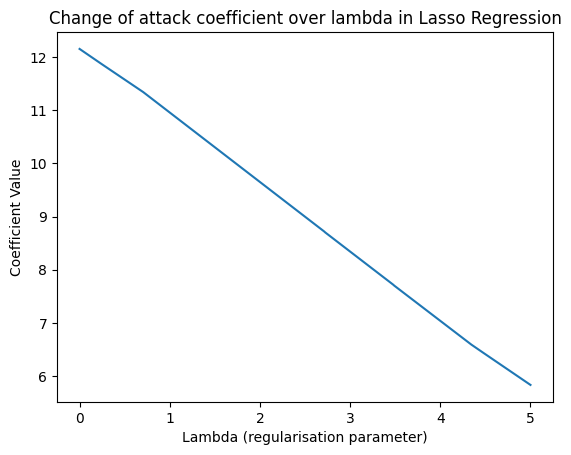

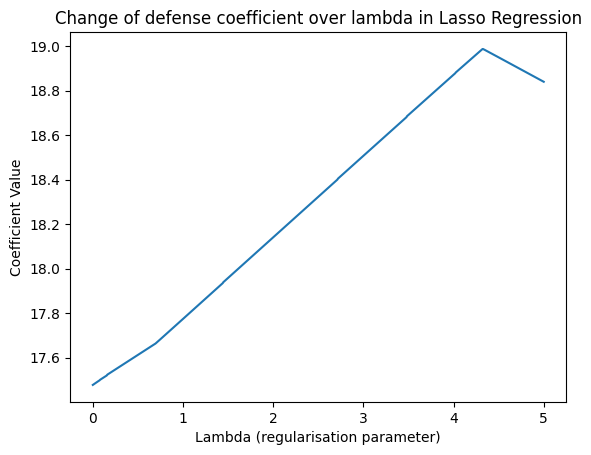

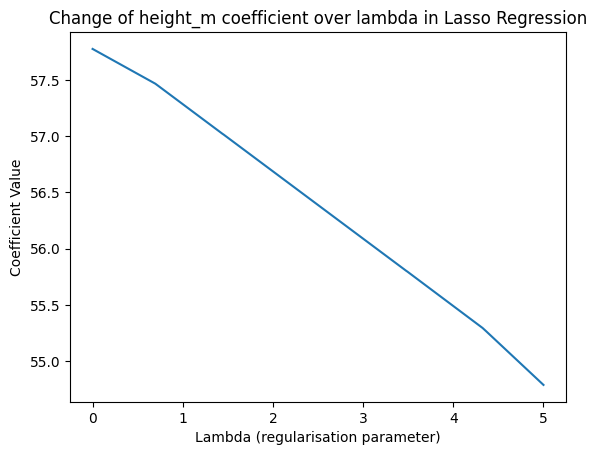

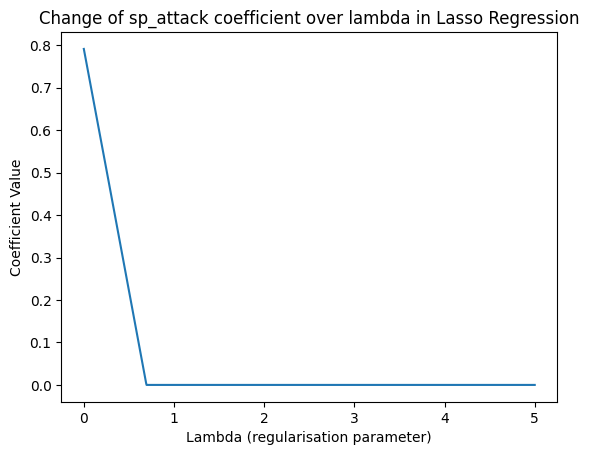

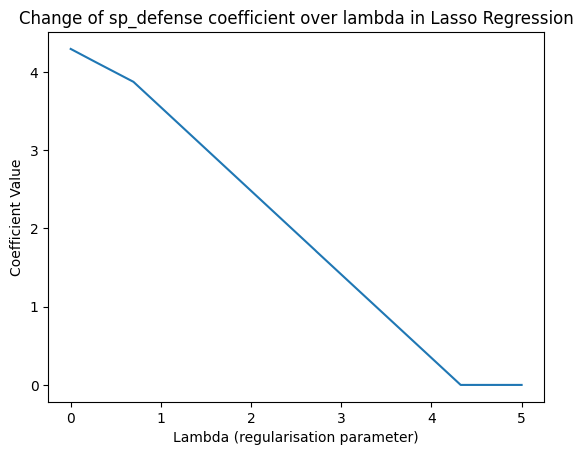

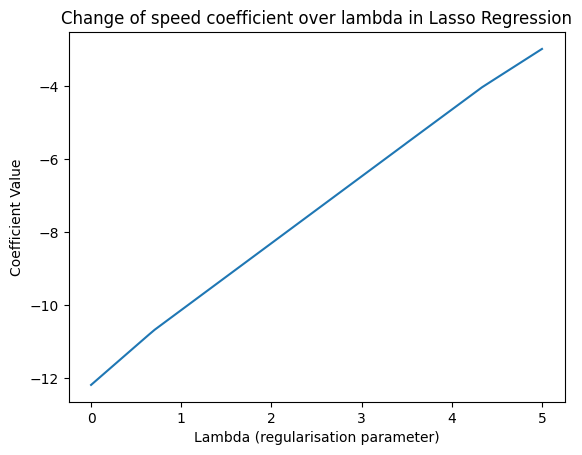

In [73]:
from sklearn.linear_model import Ridge, Lasso
import matplotlib.pyplot as plt

from typing import List

def get_pokemon_df() -> pd.DataFrame:
    return pd.read_csv("./datasets/pokemonregr.csv", sep=",")

pokemon_df: pd.DataFrame = get_pokemon_df().dropna()
pokemon_X: pd.DataFrame = pokemon_df.iloc[:, :-1]
pokemon_y: pd.DataFrame = pokemon_df.iloc[:, -1]

def plot_ridge_coefs(lambda_grid: np.ndarray, X: pd.DataFrame, y: pd.DataFrame) -> None:
    predictor_names: List[str] = X.columns.to_list()
    coef_values: List[np.ndarray] = []

    X_array: np.ndarray = X.to_numpy()
    y_array: np.ndarray = y.to_numpy()

    scaler = StandardScaler()
    X_array = scaler.fit_transform(X_array)

    for lambda_val in lambda_grid:
        model: Ridge = Ridge(alpha=lambda_val).fit(X_array, y_array)
        coef_values.append(model.coef_)
    
    coefs: np.ndarray = np.array(coef_values).T

    for i in range(0, len(predictor_names)):
        row: np.ndarray = coefs[i]
        plt.plot(lambda_grid, row, label=predictor_names[i])
        plt.title(f"Change of {predictor_names[i]} coefficient over lambda in Ridge Regression")
        plt.xlabel("Lambda (regularisation parameter)")
        plt.ylabel("Coefficient Value")
        plt.show()

def plot_lasso_coefs(lambda_grid: np.ndarray, X: pd.DataFrame, y: pd.DataFrame) -> None:
    predictor_names: List[str] = X.columns.to_list()
    coef_values: List[np.ndarray] = []

    X_array: np.ndarray = X.to_numpy()
    y_array: np.ndarray = y.to_numpy()

    scaler = StandardScaler()
    X_array = scaler.fit_transform(X_array)

    for lambda_val in lambda_grid:
        model: Ridge = Lasso(alpha=lambda_val).fit(X_array, y_array)
        coef_values.append(model.coef_)
    
    coefs: np.ndarray = np.array(coef_values).T

    for i in range(0, len(predictor_names)):
        row: np.ndarray = coefs[i]
        plt.plot(lambda_grid, row, label=predictor_names[i])
        plt.title(f"Change of {predictor_names[i]} coefficient over lambda in Lasso Regression")
        plt.xlabel("Lambda (regularisation parameter)")
        plt.ylabel("Coefficient Value")
        plt.show()

plot_ridge_coefs(np.linspace(0, 5, num=1000), pokemon_X, pokemon_y)
plot_lasso_coefs(np.linspace(0, 5, num=1000), pokemon_X, pokemon_y)